<a href="https://colab.research.google.com/github/austinmallie/ADS599_Capstone/blob/main/EDA/Breach_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Data & Libraries


In [1]:
from google.colab import userdata
import os

token = userdata.get('Github')
owner = "austinmallie"
repo = "ADS599_Capstone"
repo_url = f"https://{token}@github.com/{owner}/{repo}.git"

# Only clone if the folder doesn't exist already
if not os.path.exists(repo):
    !git clone {repo_url}
else:
    print("Repo already cloned. Pulling latest changes...")
    %cd {repo}
    !git pull

%cd /content/{repo}

Repo already cloned. Pulling latest changes...
/content/ADS599_Capstone
Already up to date.
/content/ADS599_Capstone


In [2]:
# Create the EDA directory if it doesn't exist
folder_name = "EDA"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

In [3]:
target_file_path = 'Data-Folder/Breach-Data/Completed_breach_report.csv'

if os.path.isdir(folder_name):
    print(f"✅ Confirmation: '{folder_name}' folder exists.")

    # Check for the file in the subfolder
    if os.path.exists(target_file_path):
        print(f"✅ Data File Found: '{target_file_path}' is ready for analysis.")
    else:
        print(f"❌ Error: File NOT found at {target_file_path}.")
        # Debug: Let's see what is inside the Breach-Data folder
        if os.path.exists('Data-Folder/Breach-Data'):
            print("Contents of Breach-Data folder:", os.listdir('Data-Folder/Breach-Data'))
else:
    print(f"❌ Error: '{folder_name}' was not found.")

✅ Confirmation: 'EDA' folder exists.
✅ Data File Found: 'Data-Folder/Breach-Data/Completed_breach_report.csv' is ready for analysis.


In [4]:
#library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#import data
df = pd.read_csv("Data-Folder/Breach-Data/Completed_breach_report.csv")
df.head()

,javax.faces.component.UIPanel@5517616a,State,Covered Entity Type,Individuals Affected,Breach Submission Date,Type of Breach,Location of Breached Information,javax.faces.component.UIPanel@55f85fe,Web Description
0,La Pine Community Health Center,OR,Healthcare Provider,1190.0,02/05/2026,Hacking/IT Incident,Desktop Computer,Yes,"The covered entity (CE), La Pine Community Hea..."
1,Ko-Kwel Wellness Center,OR,Healthcare Provider,543.0,02/03/2026,Hacking/IT Incident,Network Server,Yes,"The covered entity (CE), Ko-Kwel Wellness Cent..."
2,LifeLong Medical Care,CA,Healthcare Provider,70000.0,01/30/2026,Unauthorized Access/Disclosure,Other,Yes,"The covered entity (CE), LifeLong Medical Care..."
3,Chattanooga C.A.R.E.S. d/b/a Cempa Community Care,TN,Healthcare Provider,1341.0,01/30/2026,Unauthorized Access/Disclosure,Other,Yes,"The covered entity (CE), Chattanooga C.A.R.E.S..."
4,Axis Healthcare Group P.C.,MD,Healthcare Provider,3537.0,01/28/2026,Hacking/IT Incident,Email,No,"Axis Healthcare Group P.C., the covered entity..."


# Basic Data Information

In [6]:
#get shape
df.shape

(6703, 9)

In [7]:
#are there duplicates?
df.duplicated().sum()

np.int64(0)

In [8]:
#get datatypes
df.dtypes

,0
javax.faces.component.UIPanel@5517616a,object
State,object
Covered Entity Type,object
Individuals Affected,float64
Breach Submission Date,object
Type of Breach,object
Location of Breached Information,object
javax.faces.component.UIPanel@55f85fe,object
Web Description,object


# Data Preprocessing & Target Alignment

In [9]:
# Column Renaming (Fixing the headers)
df = df.rename(columns={
    'javax.faces.component.UIPanel@5517616a': 'Entity_Name',
    'javax.faces.component.UIPanel@55f85fe': 'Business_Associate_Involved',
    'State': 'State', # Already clean
    'Covered Entity Type': 'Entity_Type',
    'Individuals Affected': 'Individuals_Affected',
    'Breach Submission Date': 'Breach_Date',
    'Type of Breach': 'Type_of_Breach',
    'Location of Breached Information': 'Breach_Location',
    'Web Description': 'Web_Description'
})

In [10]:
# Date Standardization
df['Breach_Date'] = pd.to_datetime(df['Breach_Date'], errors='coerce')

## Review Missing Values

In [11]:
# Check for Nulls
print("--- MISSING DATA CHECK ---")
print(df.isnull().sum())

--- MISSING DATA CHECK ---
Entity_Name                      0
State                           20
Entity_Type                      5
Individuals_Affected             1
Breach_Date                      0
Type_of_Breach                   1
Breach_Location                  0
Business_Associate_Involved      0
Web_Description                200
dtype: int64


In [12]:
# Isolate the row with the missing value to show the 'Consolidated' note
missing_row = df[df['Individuals_Affected'].isnull()]

print("--- INVESTIGATING MISSING DATA ---")
print("Targeting the row where 'Individuals_Affected' is null:")
display(missing_row[['Entity_Name', 'Individuals_Affected', 'Web_Description']])

--- INVESTIGATING MISSING DATA ---
Targeting the row where 'Individuals_Affected' is null:


,Entity_Name,Individuals_Affected,Web_Description
5902,Valperaiso Fire Department,NaN,This case has been consolidated with another r...


In [13]:
# Dropping rows where 'Individuals_Affected' is NaN since the one we found is a consolidated duplicate anyway
df = df.dropna(subset=['Individuals_Affected'])

In [14]:
# Search for 'consolidated' in the Web_Description column
# We use case=False so it finds 'Consolidated', 'consolidated', or 'CONSOLIDATED'
consolidated_rows = df[df['Web_Description'].str.contains('consolidated', case=False, na=False)]

print(f"--- AUDIT: FOUND {len(consolidated_rows)} CONSOLIDATED RECORDS ---")

--- AUDIT: FOUND 81 CONSOLIDATED RECORDS ---


In [15]:
# test
df.shape

(6702, 9)

In [16]:
# Display the relevant columns to see if they are duplicates or missing data
with pd.option_context('display.max_colwidth', None):
    display(consolidated_rows[['Entity_Name', 'Entity_Type', 'Web_Description']])

,Entity_Name,Entity_Type,Web_Description
160,Vision Upright MRI,Healthcare Provider,"Vision Upright MRI (CE) reported that it had experienced unauthorized access to its server due to a faulty firewall configuration, resulting in a breach that affected 23,031 patients. OCR has consolidated all issues from this breach into a related investigation and voluntary settlement agreement.\n"
268,"Rumpke Consolidated Companies, Inc. & Affiliates Benefits Plan",Health Plan,"Rumpke Consolidated Companies & Affiliated Benefits Plan, the covered entity (CE), reported that it experienced a cyberattack that affected the protected health information (PHI) of 16,946 individuals. The PHI involved included demographic and clinical information. The CE notified HHS, affected individuals, and the media. The CE took several corrective actions in response to the breach including implementing multifactor authentication and other technical safeguards.\n"
870,Leggett & Platt Incorporated Employee Benefit Fund,Health Plan,"The covered entity (CE), Leggett & Platt Incorporated Employee Benefit Fund, reported that a software application used by its business associate (BA) exposed the protected health information (PHI) of 1,200 individuals. The PHI involved included Social Security numbers, claims, and treatment information. The CE notified HHS, the affected individuals, the media, and provided substitute notice. This case has been consolidated into another breach investigation."
1310,"Sesame, Inc.",Business Associate,"The business associate (BA), Sesame, Inc., reported that web tracking pixels transferred the protected health information (PHI) of 1,809 individuals to unauthorized third parties. OCR has consolidated this breach report into an open compliance review of the BA."
1692,Advocate Aurora Health,Healthcare Provider,"The covered entity (CE), Advocate Aurora Health, reported that web tracking technology transferred the protected health information (PHI) of 3,000,000 individuals to unauthorized recipients. OCR has consolidated this breach report into an existing compliance review of the CE."
...,...,...,...
6111,Miami Beach Healthcare Group Ltd. dba Aventura Hospital and Medical Center,Healthcare Provider,This case has been consolidated with another review of the same covered entity.
6114,Henry Ford Health System,Healthcare Provider,"Henry Ford Health System, the covered entity (CE) reported breaches that occurred on September 24, 2010, January 31, 2011, August 5, 2011, and October 23, 2014. OCR consolidated the breaches into one investigation because the breaches contained similar issues and each breach involved employees who failed to follow the CE’s policies or procedures. The September 24, 2010, breach affected 3,700 individuals and occurred when a laptop computer was stolen from an office left unlocked by an employee for approximately four hours while the employee was attending a meeting. The January 31, 2011, breach affected 2,777 individuals and occurred when an employee lost a personal portable electronic device (a “flash” drive) containing protected health information (PHI). The August 5, 2011, breach affected 520 individuals and occurred when an unencrypted desktop computer was stolen from a lab with secure access for workforce members. The desktop computer had been purchased directly by the department instead of through the CE’s established computer purchase procedures. The October 23, 2014, breach affected 2,336 individuals and occurred when a physician lost a flash drive. The physician failed to adhere to the CE’s policy mandating use of the CE’s issued flash drives and padlock. The PHI involved in the breaches included clinical and demographic information. The CE provided breach notification to the affected individuals, the media, and HHS. To resolve the issues raised in these matters, the CE took the following voluntary actions: 1) sanctioned the employees involved in the breaches depending on the severity of the employees’ noncompliance

In [17]:
# Will drop lines where case has been cosolidated
# Will use RegEx to capture phrases with consolidated, while ignoring company names that include Consolidated

# Create a list of phrases or patterns to exclude
patterns_to_remove = [
    'OCR has consolidated',
    'case has been consolidated',
    'consolidated with another report',
    'consolidated with another case'
]

# Combine them into one regex string
regex_pattern = '|'.join(patterns_to_remove)

# Filter the dataframe:
df = df[~df['Web_Description'].str.contains('|'.join(patterns_to_remove), case=False, na=False)]

display(df[['Entity_Name', 'Web_Description']])


,Entity_Name,Web_Description
0,La Pine Community Health Center,"The covered entity (CE), La Pine Community Hea..."
1,Ko-Kwel Wellness Center,"The covered entity (CE), Ko-Kwel Wellness Cent..."
2,LifeLong Medical Care,"The covered entity (CE), LifeLong Medical Care..."
3,Chattanooga C.A.R.E.S. d/b/a Cempa Community Care,"The covered entity (CE), Chattanooga C.A.R.E.S..."
4,Axis Healthcare Group P.C.,"Axis Healthcare Group P.C., the covered entity..."
...,...,...
6698,"Mark D. Lurie, MD",A shared Computer that was used for backup was...
6699,Health Services for Children with Special Need...,A laptop was lost by an employee while in tran...
6700,Alaska Department of Health and Social Services,The Alaska Department of Health and Social Ser...
6701,"Mid America Kidney Stone Association, LLC",Five desktop computers containing unencrypted ...


In [18]:
# Fill State and Entity Type with 'Unknown'
df['State'] = df['State'].fillna('Unknown')
df['Entity_Type'] = df['Entity_Type'].fillna('Unknown')

# Fill the single missing Breach Type with 'Other'
df['Type_of_Breach'] = df['Type_of_Breach'].fillna('Other')

# Fill Web Description so the Null count goes to zero
df['Web_Description'] = df['Web_Description'].fillna('No description provided')

# Final Verification
print("--- FINAL MISSING DATA CHECK ---")
print(df.isnull().sum())

# Show a few 'Unknown' states to confirm it worked
display(df[df['State'] == 'Unknown'].head(3))

--- FINAL MISSING DATA CHECK ---
Entity_Name                    0
State                          0
Entity_Type                    0
Individuals_Affected           0
Breach_Date                    0
Type_of_Breach                 0
Breach_Location                0
Business_Associate_Involved    0
Web_Description                0
dtype: int64


,Entity_Name,State,Entity_Type,Individuals_Affected,Breach_Date,Type_of_Breach,Breach_Location,Business_Associate_Involved,Web_Description
369,La Liga Puertorriquena Contra El Cancer DBA Ho...,Unknown,Healthcare Provider,4590.0,2024-09-16,Hacking/IT Incident,Email,No,"The covered entity (CE), La Liga Puertorriquen..."
376,Oficina Medica,Unknown,Healthcare Provider,2618.0,2024-09-08,Theft,"Desktop Computer, Other Portable Electronic De...",No,"The covered entity (CE), Oficina Medica, repor..."
379,Guam Seventh-Day Adventist Clinic,Unknown,Healthcare Provider,56635.0,2024-09-06,Hacking/IT Incident,Email,No,"Guam Seventh-Day Adventist Clinic, the covered..."


## Clean up Type_of_Breach

In [19]:
# Review breaches by Type
# Calculate the frequency of each breach type
type_counts = df['Type_of_Breach'].value_counts()

# Print the exact numbers for your report
print("--- BREACH TYPE FREQUENCY ---")
print(type_counts)

--- BREACH TYPE FREQUENCY ---
Type_of_Breach
Hacking/IT Incident                                                                                    3696
Unauthorized Access/Disclosure                                                                         1495
Theft                                                                                                   991
Loss                                                                                                    215
Improper Disposal                                                                                       114
Other                                                                                                    75
Theft, Unauthorized Access/Disclosure                                                                    25
Loss, Theft                                                                                              15
Unknown                                                                                    

In [20]:
# Some lines have multiple selections for breach type
# "Hacking" is considered a higher-tier threat than "Theft," so we'll create a script that looks at the string and assigns a single, primary category based on a hierarchy

def simplify_breach(type_str):
    """
    Groups messy multi-label breach types into 5 clean,
    mutually exclusive categories based on priority.
    """
    type_str = str(type_str)
    # Hacking is the highest priority for our project
    if 'Hacking' in type_str:
        return 'Hacking/IT Incident'
    elif 'Theft' in type_str:
        return 'Theft'
    elif 'Unauthorized Access' in type_str:
        return 'Unauthorized Access/Disclosure'
    elif 'Loss' in type_str:
        return 'Loss'
    elif 'Improper Disposal' in type_str:
        return 'Improper Disposal'
    else:
        return 'Other/Unknown'

# Create the clean column for analysis and modeling
df['Main_Breach_Type'] = df['Type_of_Breach'].apply(simplify_breach)

print("Breach types consolidated into 5 clean categories.")
print(df['Main_Breach_Type'].value_counts())

Breach types consolidated into 5 clean categories.
Main_Breach_Type
Hacking/IT Incident               3711
Unauthorized Access/Disclosure    1506
Theft                             1043
Loss                               221
Improper Disposal                  114
Other/Unknown                       87
Name: count, dtype: int64


## Sort Chronologically

In [21]:
# Sort and Re-index
df = df.sort_values(by='Breach_Date').reset_index(drop=True)

print("✅ Data is now in chronological order.")
print(f"Oldest Breach: {df['Breach_Date'].min()}")
print(f"Newest Breach: {df['Breach_Date'].max()}")

# Preview the most recent breaches
display(df.tail())

✅ Data is now in chronological order.
Oldest Breach: 2009-10-21 00:00:00
Newest Breach: 2026-02-05 00:00:00


,Entity_Name,State,Entity_Type,Individuals_Affected,Breach_Date,Type_of_Breach,Breach_Location,Business_Associate_Involved,Web_Description,Main_Breach_Type
6677,Axis Healthcare Group P.C.,MD,Healthcare Provider,3537.0,2026-01-28,Hacking/IT Incident,Email,No,"Axis Healthcare Group P.C., the covered entity...",Hacking/IT Incident
6678,Chattanooga C.A.R.E.S. d/b/a Cempa Community Care,TN,Healthcare Provider,1341.0,2026-01-30,Unauthorized Access/Disclosure,Other,Yes,"The covered entity (CE), Chattanooga C.A.R.E.S...",Unauthorized Access/Disclosure
6679,LifeLong Medical Care,CA,Healthcare Provider,70000.0,2026-01-30,Unauthorized Access/Disclosure,Other,Yes,"The covered entity (CE), LifeLong Medical Care...",Unauthorized Access/Disclosure
6680,Ko-Kwel Wellness Center,OR,Healthcare Provider,543.0,2026-02-03,Hacking/IT Incident,Network Server,Yes,"The covered entity (CE), Ko-Kwel Wellness Cent...",Hacking/IT Incident
6681,La Pine Community Health Center,OR,Healthcare Provider,1190.0,2026-02-05,Hacking/IT Incident,Desktop Computer,Yes,"The covered entity (CE), La Pine Community Hea...",Hacking/IT Incident


# Visualizations

## Review Breaches

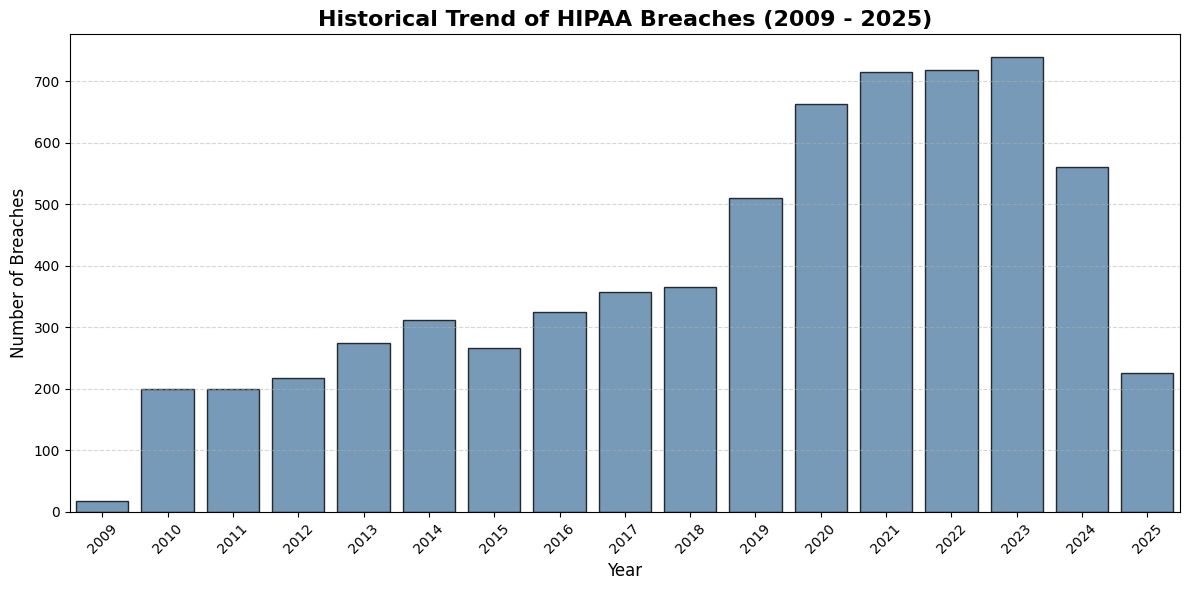

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a "Year" column to make grouping easier
df['Breach_Year'] = df['Breach_Date'].dt.year

# Count Breaches by Year to see the 'Trend'
breach_trends = df.groupby('Breach_Year').size()

# Filter out 2026 to avoid showing a "drop" due to incomplete data
plot_data = breach_trends[breach_trends.index < 2026]

plt.figure(figsize=(12, 6))
sns.barplot(x=plot_data.index, y=plot_data.values, color='steelblue', edgecolor='black', alpha=0.8)

plt.title('Historical Trend of HIPAA Breaches (2009 - 2025)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Breaches', fontsize=12)
plt.xticks(rotation=45)

# Adding a clean horizontal grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

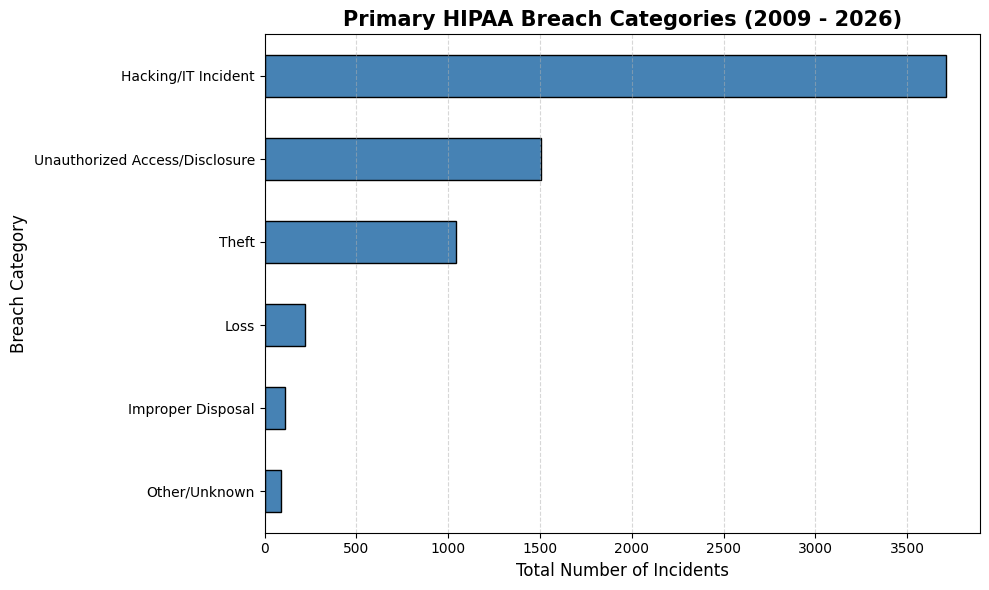

--- CLEANED BREACH CATEGORIES ---
Main_Breach_Type
Hacking/IT Incident               3711
Unauthorized Access/Disclosure    1506
Theft                             1043
Loss                               221
Improper Disposal                  114
Other/Unknown                       87
Name: count, dtype: int64


In [23]:
# Calculate the frequency of the Cleaned breach typw categories
main_type_counts = df['Main_Breach_Type'].value_counts()
plt.figure(figsize=(10, 6))
main_type_counts.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Primary HIPAA Breach Categories (2009 - 2026)', fontsize=15, fontweight='bold')
plt.xlabel('Total Number of Incidents', fontsize=12)
plt.ylabel('Breach Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Invert y-axis so 'Hacking' (the most frequent) is at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print("--- CLEANED BREACH CATEGORIES ---")
print(main_type_counts)

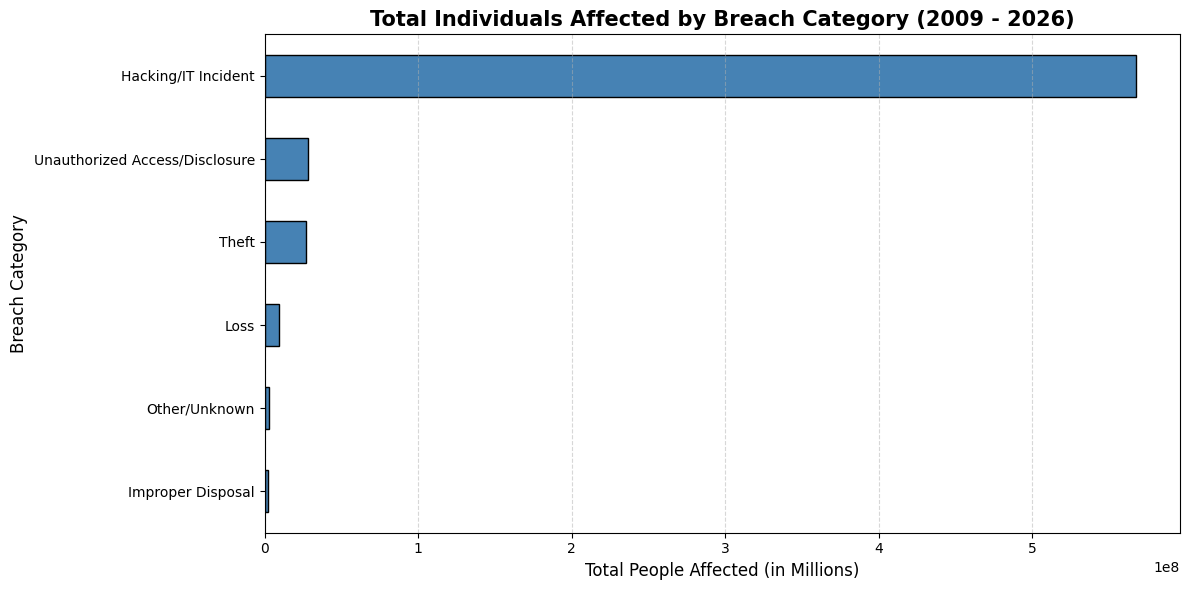

--- SEVERITY STATS BY TYPE ---
                                Total_Millions  median
Main_Breach_Type                                      
Hacking/IT Incident                     567.72  8179.0
Unauthorized Access/Disclosure           28.14  1700.0
Theft                                    27.15  2185.0
Loss                                      9.45  1900.0
Other/Unknown                             3.16  1717.0
Improper Disposal                         2.09  1879.5


In [24]:
# Visualize Individuals Affected
# Calculate Total Impact (Sum) and Typical Severity (Median)
impact_stats = df.groupby('Main_Breach_Type')['Individuals_Affected'].agg(['sum', 'median']).sort_values(by='sum', ascending=False)

# Visualize Total Impact
plt.figure(figsize=(12, 6))
impact_stats['sum'].plot(kind='barh', color='steelblue', edgecolor='black')

# Formatting for large numbers (Millions)
plt.title('Total Individuals Affected by Breach Category (2009 - 2026)', fontsize=15, fontweight='bold')
plt.xlabel('Total People Affected (in Millions)', fontsize=12)
plt.ylabel('Breach Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Print the stats
print("--- SEVERITY STATS BY TYPE ---")
# Formatting the sum to be more readable
impact_stats['Total_Millions'] = (impact_stats['sum'] / 1_000_000).round(2)
print(impact_stats[['Total_Millions', 'median']])

In [25]:
# Isolate the top 10 largest breaches
top_10_breaches = df.sort_values(by='Individuals_Affected', ascending=False).head(10)

# Display the key details
print("--- THE 10 LARGEST HIPAA BREACHES IN HISTORY ---")
display(top_10_breaches[['Entity_Name', 'State', 'Breach_Date', 'Individuals_Affected', 'Main_Breach_Type']])

# Review how much these 10 rows contribute to the total
top_10_sum = top_10_breaches['Individuals_Affected'].sum()
total_sum = df['Individuals_Affected'].sum()
percentage = (top_10_sum / total_sum) * 100

print(f"\nThese top 10 breaches alone account for {percentage:.1f}% of all affected individuals.")

--- THE 10 LARGEST HIPAA BREACHES IN HISTORY ---


,Entity_Name,State,Breach_Date,Individuals_Affected,Main_Breach_Type
1247,Anthem Inc.,IN,2015-02-13,78800000.0,Hacking/IT Incident
5744,"Welltok, Inc.",CO,2023-11-06,14782887.0,Hacking/IT Incident
2769,"Optum360, LLC",MN,2019-07-01,11500000.0,Hacking/IT Incident
5557,HCA Healthcare,TN,2023-07-31,11270000.0,Hacking/IT Incident
1269,Premera Blue Cross,WA,2015-03-17,11000000.0,Hacking/IT Incident
2791,Laboratory Corporation of America Holdings dba...,NC,2019-07-13,10251784.0,Hacking/IT Incident
1410,"Excellus Health Plan, Inc.",NY,2015-09-09,9358891.0,Hacking/IT Incident
5735,"Perry Johnson & Associates, Inc. dba PJ&A",NV,2023-11-03,9302588.0,Hacking/IT Incident
5566,"Maximus, Inc.",VA,2023-08-04,9179390.0,Hacking/IT Incident
5424,Managed Care of North America,GA,2023-05-26,8627242.0,Hacking/IT Incident



These top 10 breaches alone account for 27.3% of all affected individuals.


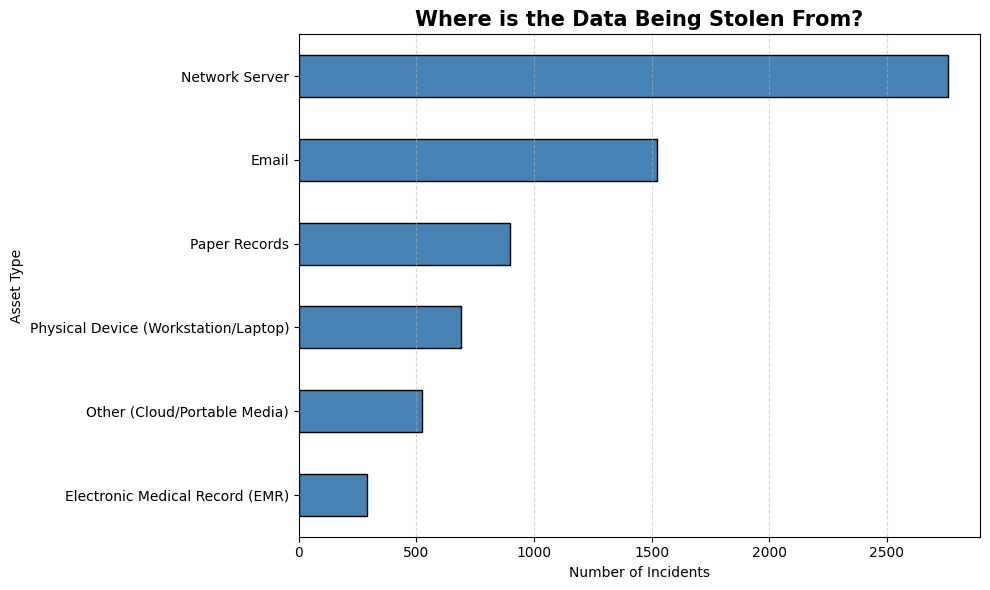

--- TOP DATA LOCATIONS ---
Main_Location
Network Server                          2759
Email                                   1523
Paper Records                            899
Physical Device (Workstation/Laptop)     691
Other (Cloud/Portable Media)             522
Electronic Medical Record (EMR)          288
Name: count, dtype: int64


In [26]:
# Clean up the 'Breach_Location'
def simplify_location(loc_str):
    loc_str = str(loc_str)
    if 'Network Server' in loc_str:
        return 'Network Server'
    elif 'Email' in loc_str:
        return 'Email'
    elif 'Laptop' in loc_str or 'Desktop' in loc_str:
        return 'Physical Device (Workstation/Laptop)'
    elif 'Paper' in loc_str:
        return 'Paper Records'
    elif 'Electronic Medical Record' in loc_str:
        return 'Electronic Medical Record (EMR)'
    else:
        return 'Other (Cloud/Portable Media)'

df['Main_Location'] = df['Breach_Location'].apply(simplify_location)

# Visualize the results
location_counts = df['Main_Location'].value_counts()

plt.figure(figsize=(10, 6))
location_counts.plot(kind='barh', color='steelblue', edgecolor='black')

plt.title('Where is the Data Being Stolen From?', fontsize=15, fontweight='bold')
plt.xlabel('Number of Incidents')
plt.ylabel('Asset Type')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print("--- TOP DATA LOCATIONS ---")
print(location_counts)

In [25]:
!git config --global user.email "cportalesloebell@sandiego.edu"
!git config --global user.name "Cynthia"

# Add all the new cleaning code and the visualizations I just made
!git add .

# Create a 'message' describing what I did
!git commit -m "Cleaned breach types and locations, added EDA visualizations"

# 3. Push to the 'main' branch
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [26]:
# Make sure you are in the right directory
%cd /content/ADS599_Capstone/

# Save the current state of your data to a CSV for model use
df.to_csv('Data-Folder/Breach-Data/Breach_Data_Cleaned.csv', index=False)

# Check what Git sees now
!git status

/content/ADS599_Capstone
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Data-Folder/Breach-Data/Breach_Data_Cleaned.csv

no changes added to commit (use "git add" and/or "git commit -a")


In [27]:
# 1. Move into the main project directory
%cd /content/ADS599_Capstone/

# 2. Remove the "submodule" link from Git's memory
!git rm --cached ADS599_Capstone

# 3. If there is a physical folder named ADS599_Capstone inside your folder, remove it
!rm -rf ADS599_Capstone

# 4. Commit this "Cleanup" to GitHub
!git add .
!git commit -m "Cleaned up accidental nested repository link"
!git push origin main

/content/ADS599_Capstone
fatal: pathspec 'ADS599_Capstone' did not match any files
[main fb396da] Cleaned up accidental nested repository link
 1 file changed, 6718 insertions(+), 6718 deletions(-)
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 55.31 KiB | 429.00 KiB/s, done.
Total 5 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/austinmallie/ADS599_Capstone.git
   644fb2c..fb396da  main -> main


In [28]:
# 1. 'Pull' the notebook you saved on GitHub into your Colab environment
!git pull origin main --rebase

# 2. Now that you are "caught up," try pushing your cleanup again
!git push origin main

From https://github.com/austinmallie/ADS599_Capstone
 * branch            main       -> FETCH_HEAD
Already up to date.
Everything up-to-date


## Data Integration

### Left Join with Hospital General Data

In [28]:
# Load post-EDA cleaned breach data
breach_clean = pd.read_csv('Data-Folder/Breach-Data/Breach_Data_Cleaned.csv')

# Load post-EDA cleaned hospital data
hospital_clean = pd.read_csv('Data-Folder/Hospital-Geneneral-Data/Hospital_General_Clean_Final.csv')

# Load the RAW dataset that still has the Facility Names to match
hospital_raw = pd.read_csv('Data-Folder/Hospital-Geneneral-Data/Hospital_General_Information.csv')

# Create a Mapping of ID to Name
names_map = hospital_raw[['Facility ID', 'Facility Name']].drop_duplicates()

# 4. Merge the names back into the clean data
hospital_clean = pd.merge(hospital_clean, names_map, on='Facility ID', how='left')

In [32]:
# Do a cleaning on names to avoid missing any matches due to punctuation or abbreviations
import re

def advanced_clean(name):
    if pd.isna(name):
        return name
    name = str(name).upper()
    # Remove punctuation (commas, periods, etc.)
    name = re.sub(r'[^\w\s]', '', name)
    # Remove common legal suffixes that cause misses
    suffixes = [' INC', ' LLC', ' CORP', ' CORPORATION', ' SYSTEM', ' HEALTHCARE', ' HEALTH']
    for s in suffixes:
        name = name.replace(s, '')
    return name.strip()

# Create the temporary matching columns
breach_clean['Entity_Clean_Match'] = breach_clean['Entity_Name'].apply(advanced_clean)
hospital_clean['Facility_Clean_Match'] = hospital_clean['Facility Name'].apply(advanced_clean)

In [37]:
# Perform the merge, but only pull in the Facility ID and Name
# Link on the cleaned names and the State to ensure accuracy
merged_df = pd.merge(
    breach_clean,
    hospital_clean[['Facility ID', 'Facility Name', 'State', 'Facility_Clean_Match']],
    left_on=['Entity_Clean_Match', 'State'],
    right_on=['Facility_Clean_Match', 'State'],
    how='left'
)

# Handle the duplicate row issue
# This prevents row inflation if two hospitals in one state have the same clean name
merged_df = merged_df.drop_duplicates(subset=['Entity_Name', 'Breach_Date', 'State'], keep='first')

# Create the indicator
merged_df['is_matched_hospital'] = merged_df['Facility ID'].notnull()

# 4. Drop the temporary cleaning columns for further merging
merged_df = merged_df.drop(columns=['Entity_Clean_Match', 'Facility_Clean_Match'])

In [41]:
# 1. Total number of breach records linked to a hospital
total_hospital_breaches = merged_df['is_matched_hospital'].sum()

# 2. Number of unique hospitals identified (Facility IDs)
unique_hospitals = merged_df[merged_df['is_matched_hospital'] == True]['Facility ID'].nunique()

print(f"Total Hospital Breach Records: {total_hospital_breaches}")
print(f"Unique Hospitals Identified: {unique_hospitals}")

Total Hospital Breach Records: 426
Unique Hospitals Identified: 331


In [49]:
merged_df.head()

,Entity_Name,State,Entity_Type,Individuals_Affected,Breach_Date,Type_of_Breach,Breach_Location,Business_Associate_Involved,Web_Description,Main_Breach_Type,Breach_Year,Main_Location,Facility ID,Facility Name,is_matched_hospital
0,BROOKE ARMY MEDICAL CENTER,TX,Healthcare Provider,1000.0,2009-10-21,Theft,Paper/Films,No,A binder containing the protected health infor...,Theft,2009,Paper Records,NaN,NaN,False
1,"MID AMERICA KIDNEY STONE ASSOCIATION, LLC",MO,Healthcare Provider,1000.0,2009-10-28,Theft,Network Server,No,Five desktop computers containing unencrypted ...,Theft,2009,Network Server,NaN,NaN,False
2,ALASKA DEPARTMENT OF HEALTH AND SOCIAL SERVICES,AK,Healthcare Provider,501.0,2009-10-30,Theft,"Other, Other Portable Electronic Device",No,The Alaska Department of Health and Social Ser...,Theft,2009,Other (Cloud/Portable Media),NaN,NaN,False
3,HEALTH SERVICES FOR CHILDREN WITH SPECIAL NEED...,DC,Health Plan,3800.0,2009-11-17,Loss,Laptop,No,A laptop was lost by an employee while in tran...,Loss,2009,Physical Device (Workstation/Laptop),NaN,NaN,False
4,"MICHELE DEL VICARIO, MD",CA,Healthcare Provider,6145.0,2009-11-20,Theft,Desktop Computer,No,A shared Computer that was used for backup was...,Theft,2009,Physical Device (Workstation/Laptop),NaN,NaN,False


## Prepare Final Cleaned Dataset

In [44]:
# Define the final list of columns
handoff_columns = [
    'Facility ID',
    'is_matched_hospital',
    'Entity_Name',
    'State',
    'Individuals_Affected',
    'Breach_Year',
    'Main_Breach_Type',
    'Main_Location',
    'Business_Associate_Involved'
]

# Create the final handoff dataframe
breach_handoff = merged_df[handoff_columns].copy()

# Rename 'Facility ID' to 'Provider_CCN'
# This matches the column name in the CMS Cost Reports
breach_handoff = breach_handoff.rename(columns={'Facility ID': 'Provider_CCN'})

# 4. Save to CSV
breach_handoff.to_csv('breach_provider_CCN.csv', index=False)

print(f"Handoff file created with {breach_handoff.shape[1]} columns.")
print(f"Ready for final merging with other datasets.")

Handoff file created with 9 columns.
Ready for final merging with other datasets.


In [50]:
# Commit to Github
# Move the file into the repo folder
!cp /content/breach_provider_CCN.csv /content/{repo}/

# Move "active directory" into that folder
%cd /content/{repo}

# Tell Git to track the file and label it and push
!git add breach_provider_CCN.csv
!git commit -m "matched breach incidents to a provider CCN to prepare for merging other datasets"
!git push origin main

cp: cannot stat '/content/breach_provider_CCN.csv': No such file or directory
/content/ADS599_Capstone
[main d70b9e3] matched breach incidents to a provider CCN to prepare for merging other datasets
 1 file changed, 6642 insertions(+)
 create mode 100644 breach_provider_CCN.csv
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 126.64 KiB | 1.46 MiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/austinmallie/ADS599_Capstone.git
   fb396da..d70b9e3  main -> main


In [51]:
!mv breach_provider_CCN.csv "Data-Folder/Breach-Data/"

# 3. Tell Git about the move (git add . handles the deletion and the new location)
!git add .
!git commit -m "Organizing: Moved breach data to Data-Folder/Breach-Data"
!git push origin main

[main 4d1125a] Organizing: Moved breach data to Data-Folder/Breach-Data
 1 file changed, 0 insertions(+), 0 deletions(-)
 rename breach_provider_CCN.csv => Data-Folder/Breach-Data/breach_provider_CCN.csv (100%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 543 bytes | 543.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/austinmallie/ADS599_Capstone.git
   d70b9e3..4d1125a  main -> main
